In [210]:
import pandas as pd

# Cargar precios ajustados
adj_close = pd.read_csv(
    "../Datos_csv/adj_close.csv",
    index_col=0,
    parse_dates=True
)

# Cargar volumen
volume = pd.read_csv(
    "../Datos_csv/volume.csv",
    index_col=0,
    parse_dates=True
)


La metodología se ilustra con un activo representativo. Seleccionamos la varibel principal (retornos en formato logarítmico)

In [211]:
import numpy as np
# Retornos
ret_simple = adj_close.pct_change()
ret_log = np.log(adj_close)
ret_log_diff = np.log(adj_close).diff() #diferencia con el dia anterior
dollar_vol = adj_close * volume


In [212]:
import matplotlib.pyplot as plt

# Elegimos un ETF para el estudio (ejemplo: SPY)
#etf = "SPY"
#etf="AGG"
etf="BND"
serie_adj_close = adj_close[etf].dropna()
serie_ret_simple = ret_simple[etf].dropna()
serie_ret_log = ret_log[etf].dropna()
serie_ret_log_diff = ret_log_diff[etf].dropna()
serie_dollar_vol = dollar_vol[etf].dropna()
serie_volume = volume[etf].dropna()

# print("ETF seleccionado:", etf)
# display(serie_ret_log.head())



Se analiza la estacionariedad de distintas transformaciones de la serie con el objetivo de identificar la representación más adecuada para la modelización temporal.

In [213]:
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning # para quitar el warning de kpss
import warnings
warnings.filterwarnings("ignore", category=InterpolationWarning)

def tests_estacionariedad(serie):
    x = np.asarray(serie, float)
    x = x[~np.isnan(x)]
    # --- ADF (H0: raíz unitaria / no estacionaria) ---
    adf_stat, adf_p, adf_lags, adf_n, adf_crit, adf_icbest = adfuller(x, autolag='AIC')
    
    # --- KPSS (H0: estacionaria) ---
    # regression='c'  -> estacionaria alrededor de una constante (nivel)
    # regression='ct' -> estacionaria alrededor de una tendencia
    kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(x, regression='c', nlags='auto' )
    if kpss_p <= 0.01 and adf_p>0.01: # rechazamos KPSS, pero no ADF
        s = "no estacionario"
    elif kpss_p > 0.01 and adf_p<=0.01: # rechazamos ADF, pero no KPSS 
        s = "estacionario"
    elif kpss_p > 0.01 and adf_p > 0.01: # no se rechaza nada        
        s = "no concluyente"
    else:
        s = "resultados inconsistentes"  # esto no debe suceder...pero sucede
    return s

In [214]:
import pandas as pd

series_a_testear = {
    "Adj_close": serie_adj_close,
    "log(Adj_close)": serie_ret_log,            
    "retorno_simple": serie_ret_simple,
    "retorno_logaritmico": serie_ret_log_diff,
    "dollar_volume": serie_dollar_vol,
    "volume": serie_volume
}

# --- Ejecutar tests y guardar resultados ---
resultados = []
for nombre, s in series_a_testear.items():
    estado = tests_estacionariedad(s)
    resultados.append({
        "ETF": etf,
        "Serie": nombre,
        "N_obs": len(s),
        "Inicio": s.index.min().date() if hasattr(s.index, "min") else None,
        "Fin": s.index.max().date() if hasattr(s.index, "max") else None,
        "Conclusión": estado
    })

res_df = pd.DataFrame(resultados)

# Imprimir bonito
#print(res_df.to_string(index=False))

# Si quieres verlo como tabla en notebook:
display(res_df)


,ETF,Serie,N_obs,Inicio,Fin,Conclusión
0,BND,Adj_close,1276,2021-01-04,2026-02-02,no estacionario
1,BND,log(Adj_close),1276,2021-01-04,2026-02-02,no estacionario
2,BND,retorno_simple,1275,2021-01-05,2026-02-02,estacionario
3,BND,retorno_logaritmico,1275,2021-01-05,2026-02-02,estacionario
4,BND,dollar_volume,1276,2021-01-04,2026-02-02,resultados inconsistentes
5,BND,volume,1276,2021-01-04,2026-02-02,estacionario


Aunque modelar el logaritmo del precio mediante un ARIMA con una diferenciación es matemáticamente equivalente a modelar los retornos logarítmicos, en este trabajo se opta por trabajar directamente con retornos. Esta elección permite una interpretación más clara de los parámetros del modelo y una integración directa con el posterior proceso de optimización de carteras, que se basa en retornos y riesgos esperados.  UTILIZAMOS DE VARIABLE PRINCIPAL LOS RETORNOS LOGARÍTMICOS

In [215]:
from pandas.tseries.offsets import DateOffset

end_date = serie_ret_log_diff.index.max()
cutoff = end_date - DateOffset(months=3)

train = serie_ret_log_diff.loc[:cutoff]
test  = serie_ret_log_diff.loc[cutoff + pd.Timedelta(days=1):]  # para que no se pise el día cutoff

print("Cutoff:", cutoff.date())
print("Train:", train.index.min().date(), "->", train.index.max().date(), "| n =", len(train))
print("Test :", test.index.min().date(),  "->", test.index.max().date(),  "| n =", len(test))

Cutoff: 2025-11-02
Train: 2021-01-05 -> 2025-10-31 | n = 1213
Test : 2025-11-03 -> 2026-02-02 | n = 62


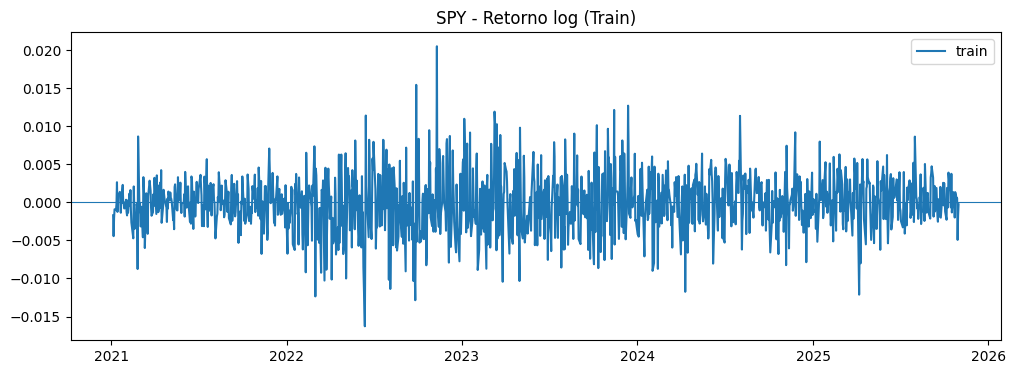

In [216]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(train, label="train")
plt.axhline(0, linewidth=0.8)
plt.title("SPY - Retorno log (Train)")
plt.legend()
plt.show()


Una serie estacionaria es un tipo de serie temporal (conjunto de observaciones ordenadas en base al
tiempo) la cual se mueve alrededor de un valor constante, es decir todos los datos tienen la misma
media, en este caso vemos que nuestros retornos SÍ siguen una media cercana al valor 0, lo que además indica ausencia de tendencia. Además, para ser serie estacionaria también tiene que tener una varianza constante y por ello no
presentar cambios en la variabilidad, pero en este caso vemos que la varianza NO es constante. HETEROCEDASTIDAD (habría qeu eliminar esta varianza cambiante)

Vamos a descomponer la serie en sus características multiplicativas para analizar mejor la estacionariedad:
Una serie temporal se puede descomponer en:


-Tendencia: Nos ayuda a determinar cuando la serie presenta un patrón creciente, decreciente, con
tendencia poco clara o sin tendencia. Cuando encontramos tendencia en nuestra serie temporal sabemos
que nuestras observaciones están relacionadas entre sí. En nuestro caso parece una serie sin tendencia clara.

-Estacionalidad: Mide si la serie se comporta diferente dentro de un periodo y si se repite el mismo compor
tamiento entre periodos. No parece que tengamos en nuestro caso estacionalidad

-Error: factores que influyen de manera aleatoria en la serie y la modifican, no son independientes, están
afectados por la tendencia y la estacionalidad.

-Ciclos: comportamientos repetidos, no tienen por qué ser entre periodos. No hya ciclos en nuestro caso.


En series temporales clásicas de nivel es habitual realizar una descomposición en tendencia, estacionalidad, ciclo y componente aleatoria, bajo esquemas aditivos o multiplicativos. Sin embargo, en el caso de los retornos financieros, esta descomposición resulta poco informativa, ya que los retornos no presentan tendencia ni estacionalidad determinista.

En la serie de retornos logarítmicos analizada, como hemso dicho, observamos estacionariedad en media, pero no lestacionariedad en varianza (heterocedasticidad).

Por este motivo, la información temporal relevante no se manifiesta a través de la tendencia o la estacionalidad, sino a través de la evolución de la volatilidad en el tiempo. Esta dinámica se modela mediante modelos de varianza condicional, como los modelos GARCH, en los que el término de error depende multiplicativamente de una varianza que cambia a lo largo del tiempo.

MIRAMOS AUTOCORRELOGRAMA SIMPLE (ACF)

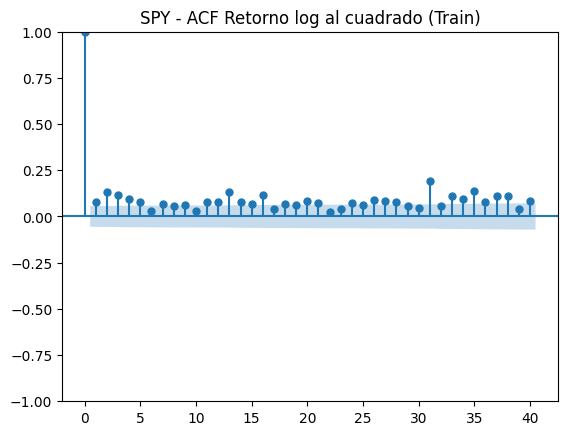

In [217]:
from statsmodels.graphics.tsaplots import plot_acf
sq_ret = train**2 #da igual q el retorno sea positivo o negativo, solo importa cómo es de grande 
plot_acf(sq_ret.dropna(), lags=40)

plt.title("SPY - ACF Retorno log al cuadrado (Train)")
plt.show()

La autocorrelación converge rápidamente a cero, lo que indica que la serie apenas depende de valores pasados. No se observan patrones de tendencia ni estacionalidad, y el comportamiento de la serie parece mayoritariamente aleatorio, salvo una ligera dependencia inicial.

- q: número de retardos significativos seguidos:2 (q=2/5) , el priemro es la relación consigo mismo por eso siempre es 1.

- Q:número de retardos estacionales significativos que se repiten
por periodos:0 (Q=0), vemos que se repite levemente al mes sig, aprox 20/23 días hábiles.

¿Los días muy movidos tienden a venir seguidos de otros días muy movidos? Sí, por eso los primeros retardos son significativos y luego cae a cero, esa relación dura poco tiempo

La media (retorno esperado) suele ser estable. El riesgo (volatilidad) cambia con el tiempo. Entonces: ARIMA → modela la media. GARCH → modela cómo cambia la volatilidad

MIRAMOS AUTOCORRELOGRAMA PARCIAL (PADF)

Analizamos el correlograma parcial. En un autocorrelograma parcial representamos el coeficiente de regresión
de Xt sobre cada individuo individualmente de Xt-k. La PACF mide la relación directa entre hoy y hace 
𝑘 días

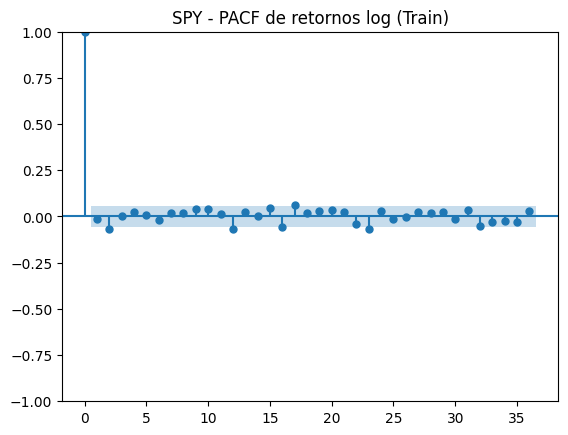

In [218]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plot_pacf(train, lags=36, method="ywm")
plt.title("SPY - PACF de retornos log (Train)")
plt.show()


La PACF sugiere que la serie solo depende de uno o dos valores pasados, sin evidencia de estacionalidad.  

- p: número de
retardos significativos en PACF:1 (p=1) 

- P: número de retardos estacionales significativos que se repiten en PACF:0 (no observamos repeticiones claras)

MODELOS ARIMA 

Ljung–Box

Hipótesis nula (H0):Los residuos NO están autocorrelados

p_value alto (> 0.05): NO rechazo H0 - HABLAMSO DE LOS RESIDUOS, CND 

p_value bajo (< 0.05): hay autocorrelación - no me intersa para los residuos, porq quiero q el modelo y la prediccion capture toda la infromacion y el residuo sea lo mas aprecido a ruido blanco, por eso quiero no rechazar la hipotesis nula.

In [219]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
# quitamos algunos warnings que no afectan pero prueden retrasar el código
from statsmodels.tools.sm_exceptions import ValueWarning,  ConvergenceWarning
warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings(
    "ignore",
    message="Non-invertible starting MA parameters found.",
    category=UserWarning
)
warnings.filterwarnings(
    "ignore",
    message="Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.",
    category=UserWarning
)
warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)



# 1) modelos a probar 
p_values = range(0, 6)   # 0..5 #cuánta dependencia directa hay con el pasado (parte AR)
q_values = range(0, 6)   # 0..5 #cuánta dependencia hay en los errores pasados (parte MA)
d = 0                    # ya tenomos retornos log => no diferenciar

resultados = []

y = train  # serie de entrenamiento
for p in p_values:
    for q in q_values:
        try:
            # 2) Ajuste ARIMA(p,0,q) sin tendencia
            res = ARIMA(y, order=(p, d, q), trend="n").fit()

            # 3) Métricas
            aic = res.aic
            bic = res.bic

            # 4) Ljung-Box en residuos, miro una anctidad concreta de autocorrelacones, en este caso las ultimas 20, y q me de el p_value del ultimo estadistico
            lb = acorr_ljungbox(res.resid.dropna(), lags=[20], return_df=True) #mide si Los residuos siguen teniendo autocorrelación
            p_value = lb["lb_pvalue"].iloc[-1]
            stat = lb["lb_stat"].iloc[-1]

            resultados.append({
                "p": p, "d": d, "q": q,
                "AIC": aic, "BIC": bic,
                "p_value": p_value,
                "Estadístico": stat #cuanto más pequeño mejor, más cercano a ruido blanco, comparar entre modelos
            })

        except Exception as e:
            # si algún modelo falla, lo saltamos
            continue

res_df = pd.DataFrame(resultados).reset_index(drop=True)
display(res_df)


,p,d,q,AIC,BIC,p_value,Estadístico
0,0,0,0,-10055.343164,-10050.242312,0.026455,33.951445
1,0,0,1,-10053.580227,-10043.378524,0.028393,33.677239
2,0,0,2,-10057.114418,-10041.811862,0.089141,28.930293
3,0,0,3,-10055.144517,-10034.741109,0.088074,28.984025
4,0,0,4,-10053.921918,-10028.417658,0.123651,27.427822
5,0,0,5,-10051.961597,-10021.356485,0.120329,27.556174
6,1,0,0,-10053.547422,-10043.345718,0.028105,33.716826
7,1,0,1,-10051.954588,-10036.652033,0.031270,33.299901
8,1,0,2,-10055.108354,-10034.704946,0.089219,28.926370
9,1,0,3,-10053.109242,-10027.604982,0.086967,29.040381


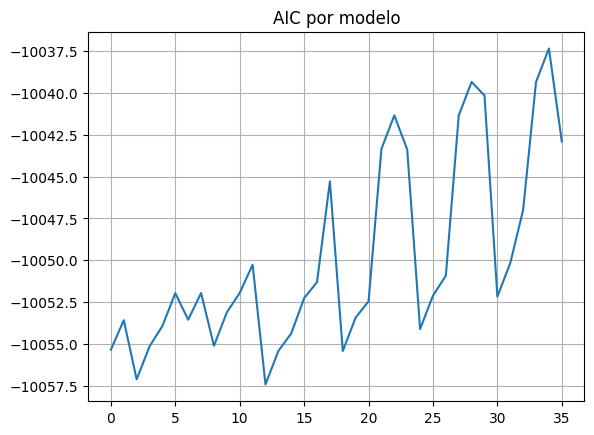

In [220]:
res_df["AIC"].plot()
plt.title("AIC por modelo")
plt.grid(True)

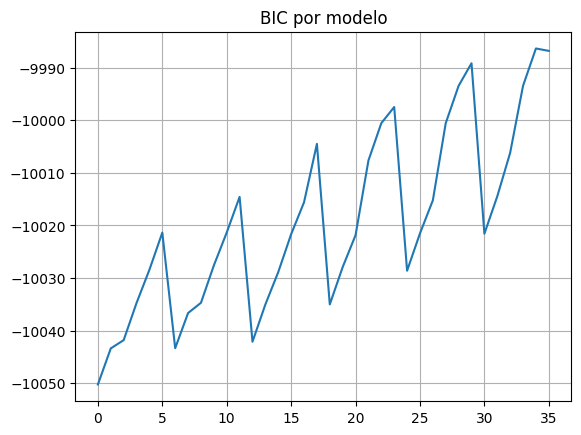

In [221]:
res_df["BIC"].plot() #BIC penaliza mucho más la complejidad.
plt.title("BIC por modelo")
plt.grid(True)

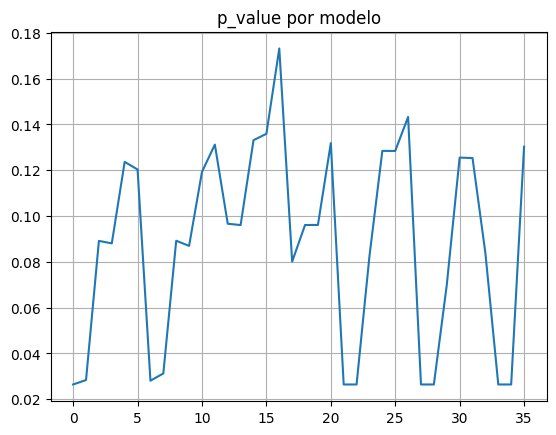

In [222]:
res_df["p_value"].plot()
plt.title("p_value por modelo")
plt.grid(True)

#hacer grafica en 3d

In [223]:
# 1) Filtrar por Ljung-Box 
cand = res_df[res_df["p_value"] > 0.05].copy()

# Si  no hay ninguno, usamos todos y seleccionamos por BIC/AIC/Estadítico
if cand.empty:
    print("Ningún modelo pasa p_value > 0.05.")
    cand = res_df.copy()

# 2) Ordenar por criterio: BIC -> AIC -> Estadístico
cand_sorted = cand.sort_values([ "AIC","BIC", "p_value"], ascending=[True, True, True])

best = cand_sorted.iloc[0]

print("Mejor modelo seleccionado:")
print(f"ARIMA({int(best['p'])}, {int(best['d'])}, {int(best['q'])})")
print(f"BIC = {best['BIC']:.6f} | AIC = {best['AIC']:.6f} | p_value = {best['p_value']:.4f} | Estadístico = {best['Estadístico']:.4f}")

best


Mejor modelo seleccionado:
ARIMA(2, 0, 0)
BIC = -10042.116804 | AIC = -10057.419360 | p_value = 0.0966 | Estadístico = 28.5669


p                  2.000000
d                  0.000000
q                  0.000000
AIC           -10057.419360
BIC           -10042.116804
p_value            0.096643
Estadístico       28.566942
Name: 12, dtype: float64

In [224]:
cand_sec = res_df[(res_df["p_value"] > 0.05) & ~((res_df["p"]==0) & (res_df["q"]==0))].copy()

cand_sorted_sec = cand_sec.sort_values(["AIC", "BIC", "p_value"], ascending=True)
best_sec = cand_sorted_sec.iloc[0]

print(best_sec[["p","d","q","BIC","AIC","p_value","Estadístico"]])

p                  2.000000
d                  0.000000
q                  0.000000
BIC           -10042.116804
AIC           -10057.419360
p_value            0.096643
Estadístico       28.566942
Name: 12, dtype: float64


p = 0 → no hay parte autorregresiva (el pasado no explica el presente)

d = 0 → la serie ya es estacionaria (correcto en retornos)

q = 0 → no hay media móvil (los errores pasados no ayudan)

El modelo es simplemente:

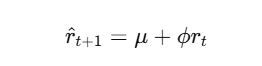

𝜇 es una media constante

𝜀 es ruido blanco (no depende del pasado)

PREDICCIÓN

Predicción “walk-forward” / rolling one-step-ahead: cada día se vuelve a ajustar el ARIMA con todo lo visto hasta ese día y se predice solo el siguiente día.

In [225]:
p = int(best_sec["p"])
d = int(best_sec["d"])   
q = int(best_sec["q"])

order = (p, d, q)
print("Usando ARIMA", order)


Usando ARIMA (2, 0, 0)


In [226]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore", category=FutureWarning)


#2) Preparar estructuras
y_train = train.copy()
y_test  = test.copy()          
y_test  = y_test.dropna()

# Creamos una serie vacía (rellena de NaNs al inicio) con el mismo índice de fechas que y_test para ir guardando la predicción de cada día del test.
pred_1step = pd.Series(index=y_test.index, dtype=float)

# DataFrame para guardar parámetros
params_df = pd.DataFrame(index=y_test.index)

# history va creciendo: empieza con train y vamos añadiendo el valor real de cada día del test
history = y_train.copy()

#  Bucle walk-forward
for dt in y_test.index:
    model = ARIMA(history, order=order, trend="n") #para q la rpedicción no sea 0, la media se le da una pequeña cte
    fit = model.fit() #Con toda la información hasta ayer, ajusta el modelo
    # Guardar parámetros (una fila por día)
    # params_df.loc[dt, fit.params.index] = fit.params.values # const es la media, ar.L1, ma.L1 coeficientes AR y MA si existen , sigma2 varianza

    # predicción 1 paso (día dt) usando información hasta el día anterior a dt
    fc = fit.forecast(steps=1) #predice el próximo valor utilziando los parametros y los datos pasados
    pred_1step.loc[dt] = fc.iloc[0]

    # actualizar history con el valor REAL observado en dt
    history.loc[dt] = y_test.loc[dt]

# Resultado + errores 
errores = y_test - pred_1step

out = pd.DataFrame({
    "real": y_test,
    "pred": pred_1step,
    "error": errores
})
# display(params_df)
display(out)
print("MAE:", errores.abs().mean())
print("RMSE:", np.sqrt((errores**2).mean()))


,real,pred,error
Date,,,
2025-11-03,-0.001158,0.000125,-0.001282
2025-11-04,0.000539,0.000035,0.000503
2025-11-05,-0.002831,0.000073,-0.002903
2025-11-06,0.003907,0.000004,0.003903
2025-11-07,-0.000538,0.000137,-0.000675
...,...,...,...
2026-01-27,-0.000807,-0.000094,-0.000714
2026-01-28,-0.000404,-0.000073,-0.000331
2026-01-29,0.000135,0.000063,0.000072


MAE: 0.0014423152179933137
RMSE: 0.0017999175713664755


MODELO BASE

El primer día del test usa el último valor del train,Luego cada día usa el valor real del día anterior

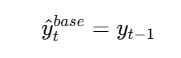

In [227]:

# MODELO BASE ( Random Walk)

# Creamos serie vacía con mismo índice que test
pred_base = pd.Series(index=y_test.index, dtype=float)

# El primer valor del test usa el último valor del train
prev_value = y_train.iloc[-1]

for dt in y_test.index:
    
    # Predicción base = último valor observado
    pred_base.loc[dt] = prev_value
    
    # Actualizamos prev_value con el valor real observado hoy
    prev_value = y_test.loc[dt]

# Errores modelo base
errores_base = y_test - pred_base

out_base = pd.DataFrame({
    "real": y_test,
    "pred_base": pred_base,
    "error_base": errores_base
})

display(out_base)

print("MAE BASE:", errores_base.abs().mean())
print("RMSE BASE:", np.sqrt((errores_base**2).mean()))


,real,pred_base,error_base
Date,,,
2025-11-03,-0.001158,-0.000268,-0.000890
2025-11-04,0.000539,-0.001158,0.001696
2025-11-05,-0.002831,0.000539,-0.003369
2025-11-06,0.003907,-0.002831,0.006738
2025-11-07,-0.000538,0.003907,-0.004445
...,...,...,...
2026-01-27,-0.000807,0.001211,-0.002019
2026-01-28,-0.000404,-0.000807,0.000403
2026-01-29,0.000135,-0.000404,0.000539


MAE BASE: 0.002096392631145651
RMSE BASE: 0.0025609799988522836


In [228]:
print("----- COMPARACIÓN -----")
print("MAE ARIMA:", errores.abs().mean())
print("MAE BASE :", errores_base.abs().mean())

print("RMSE ARIMA:", np.sqrt((errores**2).mean()))
print("RMSE BASE :", np.sqrt((errores_base**2).mean()))


----- COMPARACIÓN -----
MAE ARIMA: 0.0014423152179933137
MAE BASE : 0.002096392631145651
RMSE ARIMA: 0.0017999175713664755
RMSE BASE : 0.0025609799988522836


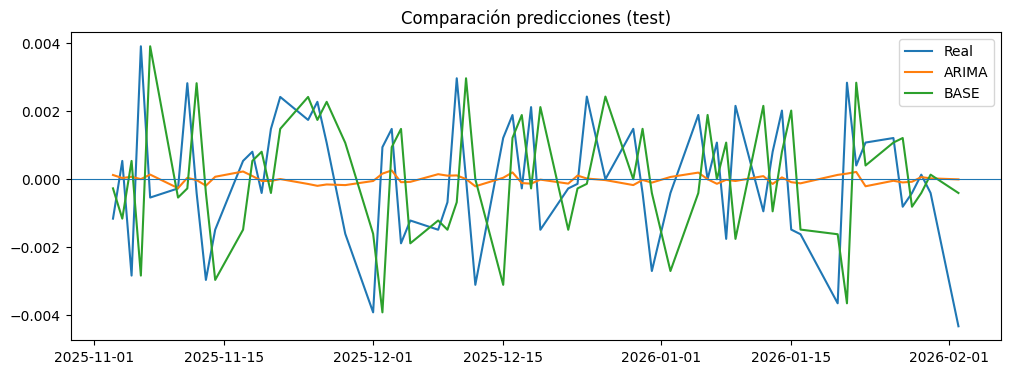

In [229]:
import matplotlib.pyplot as plt
comp = pd.DataFrame({
    "real": y_test,
    "pred_arima": pred_1step,
    "pred_base": pred_base,
})

plt.figure(figsize=(12,4))
plt.plot(comp["real"], label="Real")
plt.plot(comp["pred_arima"], label="ARIMA")
plt.plot(comp["pred_base"], label="BASE")
plt.axhline(0, linewidth=0.8)
plt.title("Comparación predicciones (test)")
plt.legend()
plt.show()


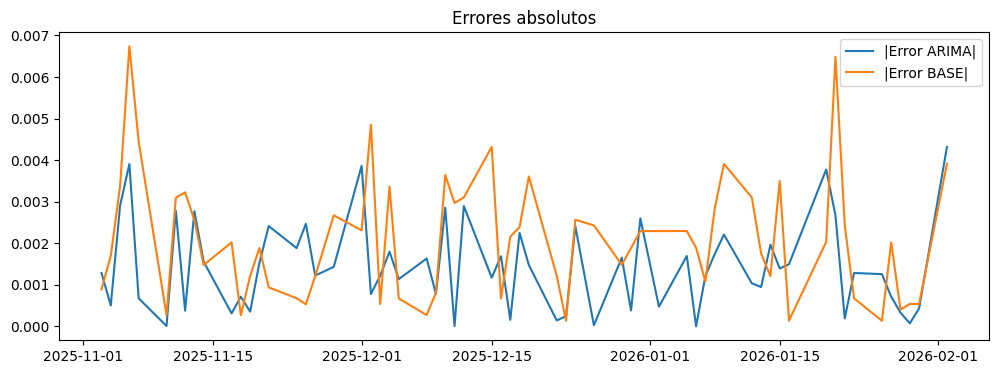

In [230]:
plt.figure(figsize=(12,4))
plt.plot(abs(errores), label="|Error ARIMA|")
plt.plot(abs(errores_base), label="|Error BASE|")
plt.legend()
plt.title("Errores absolutos")
plt.show()
